### Import Libraries

In [1]:
!pip install -q mlflow
!pip install -q pytorch-lightning
!pip install --upgrade --force-reinstall --no-deps -q kaggle
# !pip install -q kaggle
# !pip install -q dagshub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 569.1/569.1 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.4/891.4 kB 44.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


### Download Dataset from Kaggle

In [2]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

!kaggle datasets download -d "uom23mlmsc239375e/cardiac-mri-dataset-org-v4"

!unzip -q "cardiac-mri-dataset-org-v4.zip"

dataset_path = "/content/img_slices_with_ratios_v4/"

Dataset URL: https://www.kaggle.com/datasets/uom23mlmsc239375e/cardiac-mri-dataset-org-v4
License(s): unknown
100% 899M/899M [00:50<00:00, 22.8MB/s]
100% 899M/899M [00:50<00:00, 18.6MB/s]


### Mount Google Drive

In [3]:
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

code_path = "/content/drive/MyDrive/MSc-Research/cardiac-mri-segmentation"
exp_path = "/content/drive/MyDrive/MSc-Research/cardiac-mri-segmentation/experiments"

os.chdir(code_path)

Mounted at /content/drive


In [4]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

import cv2
import torch
import mlflow
import logging
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch import optim
from experiments.src.org_unet_parts import *
from dataloader.acdc_dataset import ACDCDataset
from utils.dice_score import dice_loss, dice_coeff
from utils.evaluate import evaluate
%matplotlib inline

In [5]:
os.chdir(exp_path)

In [6]:
exp_run_id = f'acdc_feedback_unet_v2_img_slices_with_ratios_v4{datetime.now().strftime("%Y%m%d%H%M%S")}'
log_file_name = f'./logs/{exp_run_id}.log'
logging.basicConfig(filename=log_file_name, level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s', force=True)

In [7]:
torch.cuda.empty_cache()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logging.info(f'Using device {device}')
print(f'Using device {device}')

Using device cuda


In [8]:
mlflow.login() # host: https://community.cloud.databricks.com/
mlflow.set_tracking_uri("databricks")

# Initialize logging - create a new MLflow Experiment
mlflow.set_experiment("/cmri-segmentation-of-ventricular-structures-and-myocardium")

2024/11/11 17:47:27 INFO mlflow.utils.credentials: No valid Databricks credentials found, please enter your credentials...


Databricks Host (should begin with https://): https://community.cloud.databricks.com/
Username: chinthalanka.23@cse.mrt.ac.lk
Password: ··········


2024/11/11 17:47:59 INFO mlflow.utils.credentials: Successfully connected to MLflow hosted tracking server! Host: https://community.cloud.databricks.com.


<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/1301949192404675', creation_time=1726678925784, experiment_id='1301949192404675', last_update_time=1731346942295, lifecycle_stage='active', name='/cmri-segmentation-of-ventricular-structures-and-myocardium', tags={'mlflow.experiment.sourceName': '/cmri-segmentation-of-ventricular-structures-and-myocardium',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'chinthalanka.23@cse.mrt.ac.lk',
 'mlflow.ownerId': '8299159887893237'}>

In [9]:
dir_checkpoint = Path('./models/checkpoints/feedback_unet_v2_img_slices_with_ratios_v4/')

epochs = 5
batch_size = 16
lr = 1e-3
scale = 1
amp = False

### Data Loading

In [10]:
# root_dir = r'../data/ACDC/img_slices_with_ratios/'
root_dir = dataset_path
logging.info(f'Using root_dir {root_dir}')

training_dataset = ACDCDataset(root_dir=root_dir, dataset='training')
validation_dataset = ACDCDataset(root_dir=root_dir, dataset='validation')
testing_dataset = ACDCDataset(root_dir=root_dir, dataset='testing')

logging.info(f'Training dataset size: {len(training_dataset)}')
logging.info(f'Validation dataset size: {len(validation_dataset)}')
logging.info(f'Testing dataset size: {len(testing_dataset)}')

# Load data from the dataset
train_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

Loaded 16000 training images
Loaded 2000 validation images
Loaded 2000 testing images


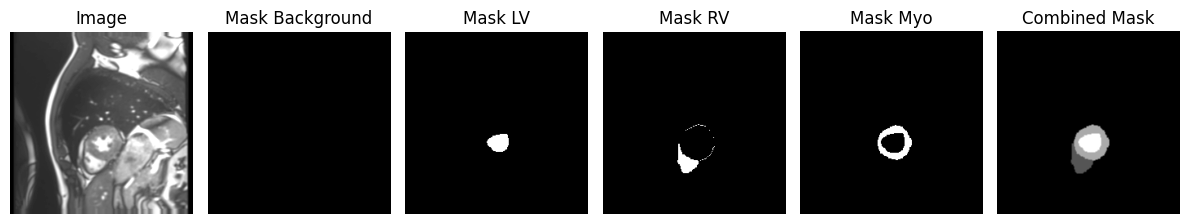

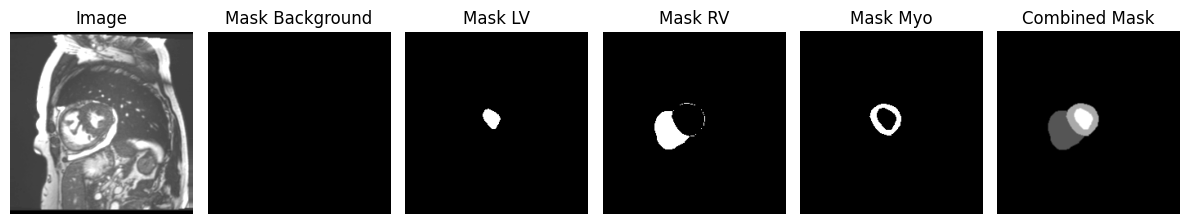

In [11]:
# Iterate through the dataset and plot the first 4 samples
n_samples_to_plot = 2

for i, sample in enumerate(test_dataloader):
    if i >= n_samples_to_plot:
        break

    # Extract data from the sample
    image = sample['image'][i].squeeze().numpy()  # Convert to numpy array
    msk_all = sample['masks_all'][i].squeeze().numpy()
    msk_bkg = sample['masks'][i][0].squeeze().numpy()
    msk_lv = sample['masks'][i][1].squeeze().numpy()
    msk_rv = sample['masks'][i][2].squeeze().numpy()
    msk_myo = sample['masks'][i][3].squeeze().numpy()

    # Create a figure with subplots
    fig, axes = plt.subplots(1, 6, figsize=(12, 5))

    # Plot the image and masks
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Image')
    axes[0].axis('off')

    axes[1].imshow(msk_bkg, cmap='gray')
    axes[1].set_title('Mask Background')
    axes[1].axis('off')

    axes[2].imshow(msk_lv, cmap='gray')
    axes[2].set_title('Mask LV')
    axes[2].axis('off')

    axes[3].imshow(msk_rv, cmap='gray')
    axes[3].set_title('Mask RV')
    axes[3].axis('off')

    axes[4].imshow(msk_myo, cmap='gray')
    axes[4].set_title('Mask Myo')
    axes[4].axis('off')

    axes[5].imshow(msk_all, cmap='gray')
    axes[5].set_title('Combined Mask')
    axes[5].axis('off')

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

### U-Net Model

In [ ]:
class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = (DoubleConv(n_channels, 64))
        self.down1 = (Down(64, 128))
        self.down2 = (Down(128, 256))
        self.down3 = (Down(256, 512))
        factor = 2 if bilinear else 1
        self.down4 = (Down(512, 1024 // factor))
        self.up1 = (Up(1024, 512 // factor, bilinear))
        self.up2 = (Up(512, 256 // factor, bilinear))
        self.up3 = (Up(256, 128 // factor, bilinear))
        self.up4 = (Up(128, 64, bilinear))
        self.outc = (OutConv(64, n_classes))

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def use_checkpointing(self):
        self.inc = torch.utils.checkpoint(self.inc)
        self.down1 = torch.utils.checkpoint(self.down1)
        self.down2 = torch.utils.checkpoint(self.down2)
        self.down3 = torch.utils.checkpoint(self.down3)
        self.down4 = torch.utils.checkpoint(self.down4)
        self.up1 = torch.utils.checkpoint(self.up1)
        self.up2 = torch.utils.checkpoint(self.up2)
        self.up3 = torch.utils.checkpoint(self.up3)
        self.up4 = torch.utils.checkpoint(self.up4)
        self.outc = torch.utils.checkpoint(self.outc)

In [ ]:
class UNetV2(nn.Module):
    def __init__(self, n_channels=1, n_classes=3, bilinear=False):
        super(UNetV2, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        # Define the encoder path (contracting path)
        self.encoder = nn.Sequential(
            self.conv_block(n_channels, 64),
            self.conv_block(64, 128),
            self.conv_block(128, 256),
            self.conv_block(256, 512)
        )

        # Define the bottleneck layer
        self.bottleneck = self.conv_block(512, 1024)

        # Define the decoder path (expansive path)
        self.decoder = nn.Sequential(
            self.up_conv_block(1024, 512),
            self.up_conv_block(512, 256),
            self.up_conv_block(256, 128),
            self.up_conv_block(128, 64)
        )

        # Final convolution layer to map to the output masks (LV, RV, MYO)
        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def up_conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
            self.conv_block(out_channels, out_channels)
        )

    def forward(self, x):
        # Encoder path
        e1 = self.encoder[0](x)
        e2 = self.encoder[1](e1)
        e3 = self.encoder[2](e2)
        e4 = self.encoder[3](e3)

        # Bottleneck
        b = self.bottleneck(e4)

        # Decoder path with skip connections
        d1 = self.decoder[0](b) + e4
        d2 = self.decoder[1](d1) + e3
        d3 = self.decoder[2](d2) + e2
        d4 = self.decoder[3](d3) + e1

        # Final layer
        out = self.final_conv(d4)
        return out

    def use_checkpointing(self):
        self.encoder[0] = torch.utils.checkpoint(self.encoder[0])
        self.encoder[1] = torch.utils.checkpoint(self.encoder[1])
        self.encoder[2] = torch.utils.checkpoint(self.encoder[2])
        self.encoder[3] = torch.utils.checkpoint(self.encoder[3])
        self.bottleneck = torch.utils.checkpoint(self.bottleneck)
        self.decoder[0] = torch.utils.checkpoint(self.decoder[0])
        self.decoder[1] = torch.utils.checkpoint(self.decoder[1])
        self.decoder[2] = torch.utils.checkpoint(self.decoder[2])
        self.decoder[3] = torch.utils.checkpoint(self.decoder[3])
        self.final_conv = torch.utils.checkpoint(self.final_conv)

### Attention UNet

In [ ]:
# Attention U-Net Model
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        # Resize g1 to match x1 dimensions if necessary
        if g1.size() != x1.size():
            g1 = nn.functional.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=True)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, n_channels=1, n_classes=4, bilinear=False):
        super(AttentionUNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.encoder = nn.Sequential(
            nn.Conv2d(self.n_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.att_block = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.decoder = nn.Sequential(
            nn.Conv2d(64, self.n_classes, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        enc = self.encoder(x)
        pooled = self.pool(enc)
        attn = self.att_block(pooled, enc)

        # Resize attn to match enc dimensions if necessary
        if attn.size() != enc.size():
            attn = nn.functional.interpolate(attn, size=enc.shape[2:], mode='bilinear', align_corners=True)

        dec = self.decoder(attn)
        return dec

#### Feedback UNet

In [ ]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size):
        super(ConvLSTMCell, self).__init__()
        padding = kernel_size // 2  # Calculate padding to maintain spatial dimensions
        self.input_channels = input_channels
        self.hidden_channels = hidden_channels
        self.kernel_size = kernel_size

        # Convolution to compute input, forget, output, and cell gates
        self.conv = nn.Conv2d(input_channels + hidden_channels, 4 * hidden_channels, kernel_size, padding=padding)

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state  # Current hidden and cell states
        _, _, height, width = input_tensor.shape # Get the spatial dimensions of the input tensor

        # Ensure hidden state has the same spatial dimensions as input
        if h_cur.shape[2] != height or h_cur.shape[3] != width:
            h_cur = F.interpolate(h_cur, size=(height, width), mode='bilinear', align_corners=False)
            c_cur = F.interpolate(c_cur, size=(height, width), mode='bilinear', align_corners=False)

        # Concatenate input and hidden state along the channel dimension
        combined = torch.cat([input_tensor, h_cur], dim=1)  # concatenate along channel axis
        combined_conv = self.conv(combined)  # Apply convolution
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_channels, dim=1)  # Split into gates

        # Apply activations for input, forget, output, and cell gates
        i = torch.sigmoid(cc_i)  # Input gate
        f = torch.sigmoid(cc_f)  # Forget gate
        o = torch.sigmoid(cc_o)  # Output gate
        g = torch.tanh(cc_g)  # Cell gate

        # Compute next cell and hidden states
        c_next = f * c_cur + i * g  # Update cell state
        h_next = o * torch.tanh(c_next)  # Update hidden state

        return h_next, c_next

    def init_hidden(self, batch_size, image_size):
        height, width = image_size
        # Initialize hidden and cell states with zeros
        return (Variable(torch.zeros(batch_size, self.hidden_channels, height, width)).cuda(),
                Variable(torch.zeros(batch_size, self.hidden_channels, height, width)).cuda())


class FeedbackUNet(nn.Module):
    def __init__(self, input_channels, num_classes):
        super(FeedbackUNet, self).__init__()
        self.n_channels = input_channels
        self.n_classes = num_classes
        self.bilinear = False

        # Encoder
        self.conv1 = nn.Conv2d(input_channels, 8, kernel_size=3, padding=1)  # First convolution layer
        self.convlstm1 = ConvLSTMCell(8, 8, kernel_size=3)  # ConvLSTM layer to capture temporal dependencies

        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)  # Second convolution layer
        self.convlstm2 = ConvLSTMCell(16, 16, kernel_size=3)  # ConvLSTM layer for deeper features

        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # Third convolution layer
        self.conv4 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # Fourth convolution layer

        # Bottleneck
        self.convlstm_bottleneck = ConvLSTMCell(64, 128, kernel_size=3)  # ConvLSTM at bottleneck to capture features

        # Decoder
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)  # Upsampling layer
        self.conv5 = nn.Conv2d(128, 64, kernel_size=3, padding=1)  # Convolution after upsampling

        self.upconv2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)  # Second upsampling layer
        self.conv6 = nn.Conv2d(64, 32, kernel_size=3, padding=1)  # Convolution after upsampling

        self.upconv3 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)  # Third upsampling layer
        self.convlstm3 = ConvLSTMCell(32, 16, kernel_size=3)  # ConvLSTM layer to refine features

        self.upconv4 = nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2)  # Fourth upsampling layer
        self.conv7 = nn.Conv2d(16, 8, kernel_size=3, padding=1)  # Convolution after upsampling
        self.convlstm4 = ConvLSTMCell(16, 8, kernel_size=3)  # ConvLSTM layer for final refinement

        # Final output
        self.final_conv = nn.Conv2d(8, num_classes, kernel_size=1)  # 1x1 convolution to produce output masks

    def forward(self, x):
        batch_size, _, height, width = x.size()

        # First round - Encoder
        x1 = F.relu(self.conv1(x))  # Apply first convolution and ReLU
        h1, c1 = self.convlstm1.init_hidden(batch_size, (height, width))  # Initialize hidden states
        h1, c1 = self.convlstm1(x1, (h1, c1))  # Apply ConvLSTM
        x1_pooled = F.max_pool2d(h1, kernel_size=2)  # Downsample with max pooling

        x2 = F.relu(self.conv2(x1_pooled))  # Apply second convolution and ReLU
        h2, c2 = self.convlstm2.init_hidden(batch_size, (height // 2, width // 2))  # Initialize hidden states
        h2, c2 = self.convlstm2(x2, (h2, c2))  # Apply ConvLSTM
        x2_pooled = F.max_pool2d(h2, kernel_size=2)  # Downsample with max pooling

        x3 = F.relu(self.conv3(x2_pooled))  # Apply third convolution and ReLU
        x3_pooled = F.max_pool2d(x3, kernel_size=2)  # Downsample with max pooling

        x4 = F.relu(self.conv4(x3_pooled))  # Apply fourth convolution and ReLU
        x4_pooled = F.max_pool2d(x4, kernel_size=2)  # Downsample with max pooling

        # Bottleneck
        h_b, c_b = self.convlstm_bottleneck.init_hidden(batch_size, (height // 16, width // 16))  # Initialize hidden states
        h_b, c_b = self.convlstm_bottleneck(x4_pooled, (h_b, c_b))  # Apply ConvLSTM at bottleneck

        # Decoder
        x5 = self.upconv1(h_b)  # Upsample the bottleneck output
        x5 = F.pad(x5, (0, x4.size(3) - x5.size(3), 0, x4.size(2) - x5.size(2)))  # Pad to match the encoder feature map size
        x5 = torch.cat([x5, x4], dim=1)  # Concatenate with corresponding encoder output
        x5 = F.relu(self.conv5(x5))  # Apply convolution and ReLU

        x6 = self.upconv2(x5)  # Upsample
        x6 = F.pad(x6, (0, x3.size(3) - x6.size(3), 0, x3.size(2) - x6.size(2)))  # Pad to match the encoder feature map size
        x6 = torch.cat([x6, x3], dim=1)  # Concatenate with corresponding encoder output
        x6 = F.relu(self.conv6(x6))  # Apply convolution and ReLU

        x7 = self.upconv3(x6)  # Upsample
        x7 = F.pad(x7, (0, x2.size(3) - x7.size(3), 0, x2.size(2) - x7.size(2)))  # Pad to match the encoder feature map size
        x7 = torch.cat([x7, x2], dim=1)  # Concatenate with corresponding encoder output
        h3, c3 = self.convlstm3.init_hidden(batch_size, (height // 4, width // 4))  # Initialize hidden states
        h3, c3 = self.convlstm3(x7, (h3, c3))  # Apply ConvLSTM

        x8 = self.upconv4(h3)  # Upsample
        x8 = F.pad(x8, (0, x1.size(3) - x8.size(3), 0, x1.size(2) - x8.size(2)))  # Pad to match the encoder feature map size
        x8 = torch.cat([x8, x1], dim=1)  # Concatenate with corresponding encoder output
        h4, c4 = self.convlstm4.init_hidden(batch_size, (height // 2, width // 2))  # Initialize hidden states
        h4, c4 = self.convlstm4(x8, (h4, c4))  # Apply ConvLSTM

        # Final output of the first round
        out1 = self.final_conv(h4)  # Apply final 1x1 convolution to produce output masks

        # Second round - Feedback the output of the first round into the encoder
        x1 = F.relu(nn.Conv2d(self.n_classes, 8, kernel_size=3, padding=1).cuda()(out1))  # Adjust convolution to accept n_classes as input channels
        h1, c1 = self.convlstm1.init_hidden(batch_size, (height, width))  # Initialize hidden states
        h1, c1 = self.convlstm1(x1, (h1, c1))  # Apply ConvLSTM
        x1_pooled = F.max_pool2d(h1, kernel_size=2)  # Downsample with max pooling

        x2 = F.relu(self.conv2(x1_pooled))  # Apply second convolution and ReLU
        h2, c2 = self.convlstm2.init_hidden(batch_size, (height // 2, width // 2))  # Initialize hidden states
        h2, c2 = self.convlstm2(x2, (h2, c2))  # Apply ConvLSTM
        x2_pooled = F.max_pool2d(h2, kernel_size=2)  # Downsample with max pooling

        x3 = F.relu(self.conv3(x2_pooled))  # Apply third convolution and ReLU
        x3_pooled = F.max_pool2d(x3, kernel_size=2)  # Downsample with max pooling

        x4 = F.relu(self.conv4(x3_pooled))  # Apply fourth convolution and ReLU
        x4_pooled = F.max_pool2d(x4, kernel_size=2)  # Downsample with max pooling

        # Bottleneck
        h_b, c_b = self.convlstm_bottleneck.init_hidden(batch_size, (height // 16, width // 16))  # Initialize hidden states
        h_b, c_b = self.convlstm_bottleneck(x4_pooled, (h_b, c_b))  # Apply ConvLSTM at bottleneck

        # Decoder
        x5 = self.upconv1(h_b)  # Upsample the bottleneck output
        x5 = F.pad(x5, (0, x4.size(3) - x5.size(3), 0, x4.size(2) - x5.size(2)))  # Pad to match the encoder feature map size
        x5 = torch.cat([x5, x4], dim=1)  # Concatenate with corresponding encoder output
        x5 = F.relu(self.conv5(x5))  # Apply convolution and ReLU

        x6 = self.upconv2(x5)  # Upsample
        x6 = F.pad(x6, (0, x3.size(3) - x6.size(3), 0, x3.size(2) - x6.size(2)))  # Pad to match the encoder feature map size
        x6 = torch.cat([x6, x3], dim=1)  # Concatenate with corresponding encoder output
        x6 = F.relu(self.conv6(x6))  # Apply convolution and ReLU

        x7 = self.upconv3(x6)  # Upsample
        x7 = F.pad(x7, (0, x2.size(3) - x7.size(3), 0, x2.size(2) - x7.size(2)))  # Pad to match the encoder feature map size
        x7 = torch.cat([x7, x2], dim=1)  # Concatenate with corresponding encoder output
        h3, c3 = self.convlstm3.init_hidden(batch_size, (height // 4, width // 4))  # Initialize hidden states
        h3, c3 = self.convlstm3(x7, (h3, c3))  # Apply ConvLSTM

        x8 = self.upconv4(h3)  # Upsample
        x8 = F.pad(x8, (0, x1.size(3) - x8.size(3), 0, x1.size(2) - x8.size(2)))  # Pad to match the encoder feature map size
        x8 = torch.cat([x8, x1], dim=1)  # Concatenate with corresponding encoder output
        h4, c4 = self.convlstm4.init_hidden(batch_size, (height // 2, width // 2))  # Initialize hidden states
        h4, c4 = self.convlstm4(x8, (h4, c4))  # Apply ConvLSTM

        # Final output of the second round
        out2 = self.final_conv(h4)  # Apply final 1x1 convolution to produce output masks

        return out2

In [12]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size):
        super(ConvLSTMCell, self).__init__()
        padding = kernel_size // 2  # Calculate padding to maintain spatial dimensions
        self.input_channels = input_channels
        self.hidden_channels = hidden_channels
        # self.kernel_size = kernel_size
        self.padding = int((kernel_size - 1) / 2) # Ensuring correct padding calculation for any kernel size

        # Convolution to compute input, forget, output, and cell gates
        self.conv = nn.Conv2d(input_channels + hidden_channels, 4 * hidden_channels, kernel_size, padding=padding)

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state  # Current hidden and cell states
        _, _, height, width = input_tensor.shape # Get the spatial dimensions of the input tensor

        # Ensure hidden state has the same spatial dimensions as input
        if h_cur.shape[2] != height or h_cur.shape[3] != width:
            h_cur = F.interpolate(h_cur, size=(height, width), mode='bilinear', align_corners=False)
            c_cur = F.interpolate(c_cur, size=(height, width), mode='bilinear', align_corners=False)

        # Concatenate input and hidden state along the channel dimension
        combined = torch.cat([input_tensor, h_cur], dim=1)  # concatenate along channel axis
        combined_conv = self.conv(combined)  # Apply convolution
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_channels, dim=1)  # Split into gates

        # Apply activations for input, forget, output, and cell gates
        i = torch.sigmoid(cc_i)  # Input gate
        f = torch.sigmoid(cc_f)  # Forget gate
        o = torch.sigmoid(cc_o)  # Output gate
        g = torch.tanh(cc_g)  # Cell gate

        # Compute next cell and hidden states
        c_next = f * c_cur + i * g  # Update cell state
        h_next = o * torch.tanh(c_next)  # Update hidden state

        return h_next, c_next

    def init_hidden(self, batch_size, image_size):
        height, width = image_size
        # Initialize hidden and cell states with zeros
        return (Variable(torch.zeros(batch_size, self.hidden_channels, height, width)).cuda(),
                Variable(torch.zeros(batch_size, self.hidden_channels, height, width)).cuda())


class FeedbackUNetV2(nn.Module):
    def __init__(self, input_channels, num_classes):
        super(FeedbackUNetV2, self).__init__()
        self.n_channels = input_channels
        self.n_classes = num_classes
        self.bilinear = False

        # Encoder
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, padding=1)  # First convolution layer
        self.convlstm1 = ConvLSTMCell(64, 64, kernel_size=3)  # ConvLSTM layer to capture temporal dependencies

        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  # Second convolution layer
        self.convlstm2 = ConvLSTMCell(128, 128, kernel_size=3)  # ConvLSTM layer for deeper features

        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)  # Third convolution layer
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)  # Fourth convolution layer

        # Bottleneck
        self.convlstm_bottleneck = ConvLSTMCell(512, 1024, kernel_size=3)  # ConvLSTM at bottleneck to capture features

        # Decoder
        self.upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)  # Upsampling layer
        self.conv5 = nn.Conv2d(1024, 512, kernel_size=3, padding=1)  # Convolution after upsampling

        self.upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)  # Second upsampling layer
        self.conv6 = nn.Conv2d(512, 256, kernel_size=3, padding=1)  # Convolution after upsampling

        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)  # Third upsampling layer
        self.conv7 = nn.Conv2d(256, 128, kernel_size=3, padding=1)  # Convolution after upsampling

        self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)  # Fourth upsampling layer
        self.conv8 = nn.Conv2d(128, 64, kernel_size=3, padding=1)  # Convolution after upsampling

        # Final output
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)  # 1x1 convolution to produce output masks

    def forward(self, x):
        batch_size, _, height, width = x.size()

        # First round - Encoder
        x1 = F.relu(self.conv1(x))  # Apply first convolution and ReLU
        h1, c1 = self.convlstm1.init_hidden(batch_size, (height, width))  # Initialize hidden states
        h1, c1 = self.convlstm1(x1, (h1, c1))  # Apply ConvLSTM
        x1_pooled = F.max_pool2d(h1, kernel_size=2)  # Downsample with max pooling

        x2 = F.relu(self.conv2(x1_pooled))  # Apply second convolution and ReLU
        h2, c2 = self.convlstm2.init_hidden(batch_size, (height // 2, width // 2))  # Initialize hidden states
        h2, c2 = self.convlstm2(x2, (h2, c2))  # Apply ConvLSTM
        x2_pooled = F.max_pool2d(h2, kernel_size=2)  # Downsample with max pooling

        x3 = F.relu(self.conv3(x2_pooled))  # Apply third convolution and ReLU
        x3_pooled = F.max_pool2d(x3, kernel_size=2)  # Downsample with max pooling

        x4 = F.relu(self.conv4(x3_pooled))  # Apply fourth convolution and ReLU
        x4_pooled = F.max_pool2d(x4, kernel_size=2)  # Downsample with max pooling

        # Bottleneck
        h_b, c_b = self.convlstm_bottleneck.init_hidden(batch_size, (height // 16, width // 16))  # Initialize hidden states
        h_b, c_b = self.convlstm_bottleneck(x4_pooled, (h_b, c_b))  # Apply ConvLSTM at bottleneck

        # Decoder
        x5 = self.upconv1(h_b)  # Upsample the bottleneck output
        x5 = F.pad(x5, (0, x4.size(3) - x5.size(3), 0, x4.size(2) - x5.size(2)))  # Pad to match the encoder feature map size
        x5 = torch.cat([x5, x4], dim=1)  # Concatenate with corresponding encoder output
        x5 = F.relu(self.conv5(x5))  # Apply convolution and ReLU

        x6 = self.upconv2(x5)  # Upsample
        x6 = F.pad(x6, (0, x3.size(3) - x6.size(3), 0, x3.size(2) - x6.size(2)))  # Pad to match the encoder feature map size
        x6 = torch.cat([x6, x3], dim=1)  # Concatenate with corresponding encoder output
        x6 = F.relu(self.conv6(x6))  # Apply convolution and ReLU

        x7 = self.upconv3(x6)  # Upsample
        x7 = F.pad(x7, (0, x2.size(3) - x7.size(3), 0, x2.size(2) - x7.size(2)))  # Pad to match the encoder feature map size
        x7 = torch.cat([x7, x2], dim=1)  # Concatenate with corresponding encoder output
        x7 = F.relu(self.conv7(x7))  # Apply convolution and ReLU

        x8 = self.upconv4(x7)  # Upsample
        x8 = F.pad(x8, (0, x1.size(3) - x8.size(3), 0, x1.size(2) - x8.size(2)))  # Pad to match the encoder feature map size
        x8 = torch.cat([x8, x1], dim=1)  # Concatenate with corresponding encoder output
        x8 = F.relu(self.conv8(x8))  # Apply convolution and ReLU

        # Final output of the first round
        out1 = self.final_conv(x8)  # Apply final 1x1 convolution to produce output masks

        # Second round - Feedback the output of the first round into the encoder
        x1 = F.relu(nn.Conv2d(self.n_classes, 64, kernel_size=3, padding=1).cuda()(out1))  # Adjust convolution to accept n_classes as input channels
        h1, c1 = self.convlstm1.init_hidden(batch_size, (height, width))  # Initialize hidden states
        h1, c1 = self.convlstm1(x1, (h1, c1))  # Apply ConvLSTM
        x1_pooled = F.max_pool2d(h1, kernel_size=2)  # Downsample with max pooling

        x2 = F.relu(self.conv2(x1_pooled))  # Apply second convolution and ReLU
        h2, c2 = self.convlstm2.init_hidden(batch_size, (height // 2, width // 2))  # Initialize hidden states
        h2, c2 = self.convlstm2(x2, (h2, c2))  # Apply ConvLSTM
        x2_pooled = F.max_pool2d(h2, kernel_size=2)  # Downsample with max pooling

        x3 = F.relu(self.conv3(x2_pooled))  # Apply third convolution and ReLU
        x3_pooled = F.max_pool2d(x3, kernel_size=2)  # Downsample with max pooling

        x4 = F.relu(self.conv4(x3_pooled))  # Apply fourth convolution and ReLU
        x4_pooled = F.max_pool2d(x4, kernel_size=2)  # Downsample with max pooling

        # Bottleneck
        h_b, c_b = self.convlstm_bottleneck.init_hidden(batch_size, (height // 16, width // 16))  # Initialize hidden states
        h_b, c_b = self.convlstm_bottleneck(x4_pooled, (h_b, c_b))  # Apply ConvLSTM at bottleneck

        # Decoder
        x5 = self.upconv1(h_b)  # Upsample the bottleneck output
        x5 = F.pad(x5, (0, x4.size(3) - x5.size(3), 0, x4.size(2) - x5.size(2)))  # Pad to match the encoder feature map size
        x5 = torch.cat([x5, x4], dim=1)  # Concatenate with corresponding encoder output
        x5 = F.relu(self.conv5(x5))  # Apply convolution and ReLU

        x6 = self.upconv2(x5)  # Upsample
        x6 = F.pad(x6, (0, x3.size(3) - x6.size(3), 0, x3.size(2) - x6.size(2)))  # Pad to match the encoder feature map size
        x6 = torch.cat([x6, x3], dim=1)  # Concatenate with corresponding encoder output
        x6 = F.relu(self.conv6(x6))  # Apply convolution and ReLU

        x7 = self.upconv3(x6)  # Upsample
        x7 = F.pad(x7, (0, x2.size(3) - x7.size(3), 0, x2.size(2) - x7.size(2)))  # Pad to match the encoder feature map size
        x7 = torch.cat([x7, x2], dim=1)  # Concatenate with corresponding encoder output
        x7 = F.relu(self.conv7(x7))  # Apply convolution and ReLU

        x8 = self.upconv4(x7)  # Upsample
        x8 = F.pad(x8, (0, x1.size(3) - x8.size(3), 0, x1.size(2) - x8.size(2)))  # Pad to match the encoder feature map size
        x8 = torch.cat([x8, x1], dim=1)  # Concatenate with corresponding encoder output
        x8 = F.relu(self.conv8(x8))  # Apply convolution and ReLU

        # Final output of the second round
        out2 = self.final_conv(x8)  # Apply final 1x1 convolution to produce output masks

        return out2

### Model Training

In [13]:
def train_model(
        model,
        device,
        epochs: int = 5,
        batch_size: int = 1,
        learning_rate: float = 1e-5,
        save_checkpoint: bool = True,
        img_scale: float = 0.5,
        amp: bool = False,
        weight_decay: float = 1e-8,
        momentum: float = 0.999,
        gradient_clipping: float = 1.0,
):
    n_train = len(training_dataset)
    n_val = len(validation_dataset)

    # Start an MLflow run
    with mlflow.start_run() as run:
        # Get the run_id of the current active run
        run_id = run.info.run_id

        logging.info(f'''Starting training:
            Epochs:          {epochs}
            Batch size:      {batch_size}
            Learning rate:   {learning_rate}
            Training size:   {n_train}
            Validation size: {n_val}
            Checkpoints:     {save_checkpoint}
            Device:          {device.type}
            Images scaling:  {img_scale}
            Mixed Precision: {amp}
        ''')

        params = {
            'epochs': epochs,
            'batch_size': batch_size,
            'learning_rate': learning_rate,
            'training_set_size': n_train,
            'validation_set_size': n_val,
            'img_scale': img_scale,
            'mixed_precision': amp
        }

        mlflow.log_params(params)

        # Initialize TensorBoard writer
        writer = SummaryWriter(log_dir=f'./logs/tensorboard_runs/{exp_run_id}')  # This will save logs in '/logs/tensorboard_runs/{exp_run_id}'

        # Set up the optimizer, the loss, the learning rate scheduler and the loss scaling for AMP
        # optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum, foreach=True)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay, foreach=True)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5)  # goal: maximize Dice score
        grad_scaler = torch.cuda.amp.GradScaler(enabled=amp)
        # criterion = nn.BCELoss() if model.n_classes > 1 else nn.BCEWithLogitsLoss() # nn.CrossEntropyLoss()
        criterion = nn.BCEWithLogitsLoss()
        global_step = 0

        # Begin training
        for epoch in range(1, epochs + 1):
            model.train()
            epoch_loss = 0

            with tqdm(total=n_train, desc=f'Epoch {epoch}/{epochs}', unit='img') as pbar:
                for batch in train_dataloader:
                    # images, msks_lv, msks_rv, msks_myo = batch['image'], batch['mask_lv'], batch['mask_rv'], batch['mask_myo']
                    images, masks, masks_all = batch['image'], batch['masks'], batch['masks_all']
                    images = images.permute(0, 3, 1, 2)
                    # masks_all = torch.argmax(masks_all, dim=1)
                    masks_all = masks_all.permute(0, 3, 1, 2)
                    # logging.info(f"images shape: {images.shape}")
                    # logging.info(f"true masks shape: {masks.shape}")

                    assert images.shape[1] == model.n_channels, \
                        f'Network has been defined with {model.n_channels} input channels, ' \
                        f'but loaded images have {images.shape[1]} channels. Please check that ' \
                        'the images are loaded correctly.'

                    images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                    true_masks = masks.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                    # true_masks = masks_all.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)

                    with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=amp):
                        # masks_pred = model(images).permute(1, 0, 2, 3)
                        masks_pred = model(images)
                        # logging.info(f"masks pred shape: {masks_pred.shape}")
                        if model.n_classes == 1:
                            loss_ce = criterion(masks_pred.squeeze(1), true_masks.float())
                            loss_dice = dice_loss(F.sigmoid(masks_pred.squeeze(1)), true_masks.float(), multiclass=False)
                            loss = 0.4 * loss_ce + 0.6 * loss_dice
                        else:
                            loss_ce = criterion(masks_pred, true_masks)  # true_masks.squeeze(1).long()
                            loss_dice = dice_loss(
                                # masks_pred,
                                # true_masks,
                                F.softmax(masks_pred, dim=1).float(),
                                # F.sigmoid(masks_pred > 0.5).float(),
                                true_masks.float(),
                                # F.softmax(masks_pred, dim=1).float(),
                                # F.one_hot(true_masks, model.n_classes).permute(0, 3, 1, 2).float(),
                                multiclass=True
                            )
                            loss = 0.4 * loss_ce + 0.6 * loss_dice

                    optimizer.zero_grad(set_to_none=True)
                    grad_scaler.scale(loss).backward()
                    grad_scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clipping)
                    grad_scaler.step(optimizer)
                    grad_scaler.update()

                    pbar.update(images.shape[0])
                    global_step += 1
                    epoch_loss += loss.item()
                    pbar.set_postfix(**{'loss (batch)': loss.item()})

                    # Evaluation round
                    division_step = (n_train // (5 * batch_size))
                    if division_step > 0:
                        if global_step % division_step == 0:
                            val_score = evaluate(model, val_dataloader, device, amp)
                            scheduler.step(val_score)
                            logging.info('Validation Dice score: {}'.format(val_score))

            if save_checkpoint:
                Path(dir_checkpoint).mkdir(parents=True, exist_ok=True)
                state_dict = model.state_dict()
                # state_dict['mask_values'] = training_dataset.mask_values
                torch.save(state_dict, str(dir_checkpoint / 'checkpoint_epoch{}.pth'.format(epoch)))
                logging.info(f'Checkpoint {epoch} saved!')

            # Log metrics to TensorBoard
            avg_loss = epoch_loss / len(train_dataloader)
            writer.add_scalar("Loss", avg_loss, epoch)

        # Close the writer when done
        writer.close()

        '''
        # Log train, validation and test set Dice Scores
        train_dice_score = evaluate(model, train_dataloader, device, amp).item()
        val_dice_score = evaluate(model, val_dataloader, device, amp).item()
        test_dice_score = evaluate(model, test_dataloader, device, amp).item()

        mlflow.log_metric("train_dice_score", round(train_dice_score, 4))
        mlflow.log_metric("val_dice_score", round(val_dice_score, 4))
        mlflow.log_metric("test_dice_score", round(test_dice_score, 4))

        logging.info(f'Overall Train Set Dice score: {round(train_dice_score, 4)}')
        logging.info(f'Overall Validation Set Dice score: {round(val_dice_score, 4)}')
        logging.info(f'Overall Test Dice Set score: {round(test_dice_score, 4)}')
        '''

    return run_id

### Training

In [14]:
# n_channels=3 for RGB images
# n_classes is the number of probabilities you want to get per pixel
# model = UNet(n_channels=1, n_classes=4, bilinear=False)
model = FeedbackUNetV2(input_channels=1, num_classes=4)
# model = UNetV2(n_channels=1, n_classes=3)
model = model.to(memory_format=torch.channels_last)

logging.info(f'Network:\n'
                 f'\t{model.n_channels} input channels\n'
                 f'\t{model.n_classes} output channels (classes)\n'
                 f'\t{"Bilinear" if model.bilinear else "Transposed conv"} upscaling')

model.to(device=device)

try:
    run_id = train_model(
        model=model,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp
    )
except torch.cuda.OutOfMemoryError:
    logging.error('Detected OutOfMemoryError! '
                  'Enabling checkpointing to reduce memory usage, but this slows down training. '
                  'Consider enabling AMP (--amp) for fast and memory efficient training')
    torch.cuda.empty_cache()
    model.use_checkpointing()
    run_id = train_model(
        model=model,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp
    )

Epoch 5/5: 100%|██████████| 16000/16000 [36:31<00:00,  7.30img/s, loss (batch)=0.567]
2024/11/11 21:04:58 INFO mlflow.tracking._tracking_service.client: 🏃 View run learned-duck-142 at: https://community.cloud.databricks.com/ml/experiments/1301949192404675/runs/b9f9b18329bf47f6be6321933388588e.
2024/11/11 21:04:58 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://community.cloud.databricks.com/ml/experiments/1301949192404675.


In [ ]:
# torch.cuda.empty_cache()

### Testing and Evaluation

In [15]:
def visualize_prediction(model, dataloader, device, sample_idx=0, img_idx=0, n_classes=4, combined_mask=True):
    model.eval()
    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            if i == sample_idx:
                # Extract data from the sample
                images = sample['image']
                true_masks = sample['masks']
                true_masks_all = sample['masks_all']
                print(f'images shape: {images.shape}')
                print(f'true masks shape: {true_masks.shape}')
                print(f'combined true masks shape: {true_masks_all.shape}')
                images = images.permute(0, 3, 1, 2)
                true_masks_all = true_masks_all.permute(0, 3, 1, 2)

                images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                # true_masks = true_masks.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                # true_masks_all = true_masks_all.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                # true_masks = (true_masks * 255).round().long()
                true_masks_all = (true_masks_all * 255).round().long()

                outputs = model(images)

                # Apply sigmoid to convert logits to probabilities, then threshold
                # preds = torch.sigmoid(outputs)
                preds = (outputs > 0.5).float()  # Convert to binary masks (0 or 1)
                # preds = preds.float().cpu().numpy().squeeze(1)

                # Convert logits to predicted class labels
                # preds = torch.argmax(outputs, dim=1).long()

                image = images[img_idx].cpu().squeeze()
                true_mask_all = true_masks_all[img_idx].cpu().squeeze().numpy()
                true_mask_bkg = true_masks[img_idx][0].cpu().squeeze().numpy()
                true_mask_lv = true_masks[img_idx][1].cpu().squeeze().numpy()
                true_mask_rv = true_masks[img_idx][2].cpu().squeeze().numpy()
                true_mask_myo = true_masks[img_idx][3].cpu().squeeze().numpy()

                # Apply argmax to get the class with the highest probability for each pixel
                pred_mask_all = None
                # pred_mask_all = torch.argmax(preds[img_idx], dim=0).cpu().numpy()  # Shape: (height, width)
                # pred_mask_all = preds[img_idx].cpu().numpy()

                print(f'preds shape: {preds.shape}')
                print(f'True mask unique values: {np.unique(true_mask_all)}')
                # print(f'Pred mask unique values: {np.unique(pred_mask_all)}')

                if n_classes > 1 and combined_mask:
                    fig, ax = plt.subplots(1, 6, figsize=(16, 5))
                    ax[0].imshow(image, cmap='gray')
                    ax[0].set_title('Input Image')

                    ax[1].imshow(true_mask_lv, cmap='gray')
                    ax[1].set_title('True LV')

                    ax[2].imshow(true_mask_rv, cmap='gray')
                    ax[2].set_title('True RV')

                    ax[3].imshow(true_mask_myo, cmap='gray')
                    ax[3].set_title('True MYO')

                    ax[4].imshow(true_mask_all, cmap='gray')
                    ax[4].set_title('True Mask')

                    ax[5].imshow(pred_mask_all, cmap='gray')
                    ax[5].set_title('Predicted Mask')
                elif n_classes > 1 and not combined_mask:
                    fig, ax = plt.subplots(2, 5, figsize=(15, 8))
                    ax[0][0].imshow(image, cmap='gray')
                    ax[0][0].set_title('Input Image')

                    ax[0][1].imshow(true_mask_bkg, cmap='gray')
                    ax[0][1].set_title('True Background')

                    ax[0][2].imshow(true_mask_lv, cmap='gray')
                    ax[0][2].set_title('True LV')

                    ax[0][3].imshow(true_mask_rv, cmap='gray')
                    ax[0][3].set_title('True RV')

                    ax[0][4].imshow(true_mask_myo, cmap='gray')
                    ax[0][4].set_title('True MYO')

                    ax[1][0].imshow(image, cmap='gray')
                    ax[1][0].set_title('Input Image')

                    ax[1][1].imshow(preds[img_idx][0].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][1].set_title('Pred Background')

                    ax[1][2].imshow(preds[img_idx][1].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][2].set_title('Pred LV')

                    ax[1][3].imshow(preds[img_idx][2].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][3].set_title('Pred RV')

                    ax[1][4].imshow(preds[img_idx][3].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][4].set_title('Pred MYO')
                else:
                    print(f'Image: {torch.unique(images[img_idx])}')
                    print(f'True Mask: {torch.unique(true_masks_all[img_idx])}')
                    print(f'Pred Mask: {np.unique(preds[img_idx])}')

                    fig, ax = plt.subplots(2, 2, figsize=(8, 8))
                    ax[0][0].imshow(image, cmap='gray')
                    ax[0][0].set_title('Input Image')

                    ax[0][1].imshow(true_mask_all, cmap='gray')
                    ax[0][1].set_title('True Mask')

                    ax[1][0].imshow(image, cmap='gray')
                    ax[1][0].set_title('Input Image')

                    ax[1][1].imshow(pred_mask_all, cmap='gray')
                    ax[1][1].set_title('Predicted Mask')

                plt.show()
                break  # Visualize only one image
            else:
                continue

images shape: torch.Size([16, 224, 224, 1])
true masks shape: torch.Size([16, 4, 224, 224])
combined true masks shape: torch.Size([16, 224, 224, 1])
preds shape: torch.Size([16, 4, 224, 224])
True mask unique values: [  0  21  42  64  85 105 128 149 170 192 213 234 255]


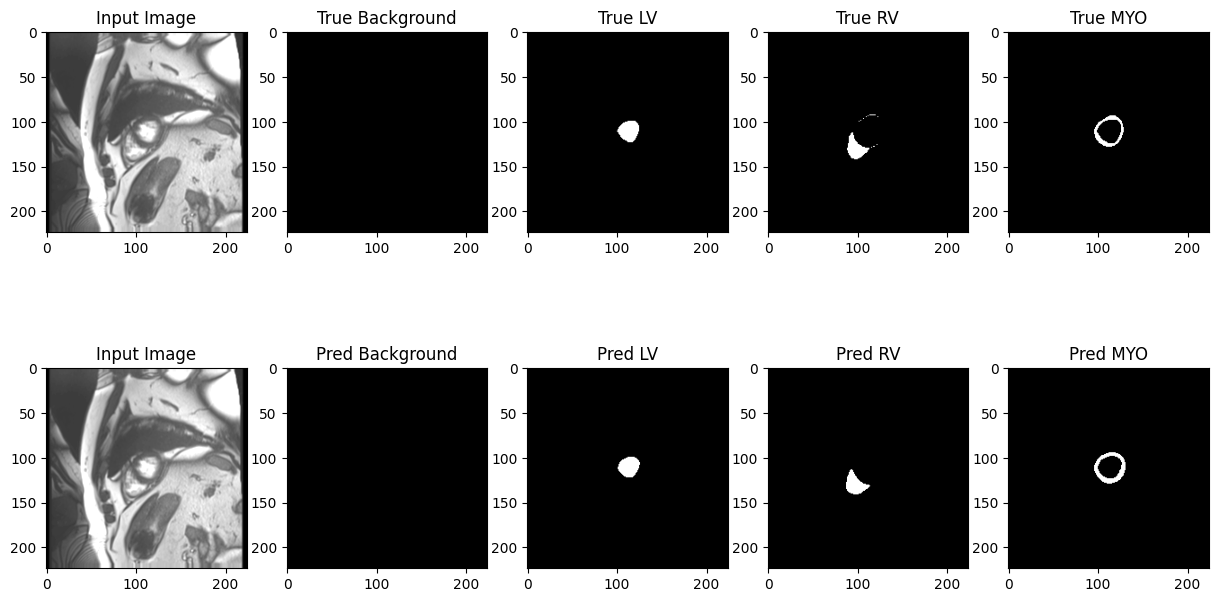

In [16]:
visualize_prediction(model, test_dataloader, device, sample_idx=1, img_idx = 6, n_classes=4, combined_mask=False)

### Model Evaluation

In [17]:
# Function to calculate Dice score for a single class
def dice_score(pred, target, smooth=1e-6):
    intersection = (pred * target).sum()
    sets_sum = pred.sum() + target.sum()
    sets_sum = torch.where(sets_sum == 0, intersection, sets_sum)
    dice = (2. * intersection + smooth) / (sets_sum + smooth)
    return dice


# Function to evaluate Dice score for each class in the test set
def evaluate_dice_score(model, dataloader, num_classes=4, device='cpu', threshold=0.5):
    model.eval()  # Set model to evaluation mode
    dice_scores = [0.0] * num_classes  # List to store Dice score for each class
    # count = 0  # Number of samples
    batch_count = len(dataloader) # Number of batches

    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            # Extract data from the sample
            images = sample['image']
            true_masks = sample['masks']
            true_masks_all = sample['masks_all']
            # print(f'images shape: {images.shape}')
            # print(f'true masks shape: {true_masks.shape}')
            # print(f'combined true masks shape: {true_masks_all.shape}')
            images = images.permute(0, 3, 1, 2)
            true_masks_all = true_masks_all.permute(0, 3, 1, 2)

            images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
            true_masks = true_masks.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)

            outputs = model(images)  # Shape: (batch_size, 4, height, width)
            # outputs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities

            # Binarize outputs based on threshold
            # predictions = (outputs > threshold).float()  # Shape: (batch_size, 4, height, width)
            predictions = (F.sigmoid(outputs) > threshold).float()

            # Calculate Dice score for each class
            for i in range(num_classes):  # Loop over each class
                dice_scores[i] += dice_coeff(
                    predictions[:, i, :, :].flatten(0, 1),
                    true_masks[:, i, :, :].flatten(0, 1),
                    reduce_batch_first=False
                    )
                '''
                dice_scores[i] += dice_score(
                    predictions[:, i, :, :],
                    true_masks[:, i, :, :]
                    )
                '''

            # count += images.size(0)  # Update sample count
            # batch_count += 1 # Update batch count

    # Average Dice scores across the dataset
    # avg_dice_scores = [score / count for score in dice_scores]
    avg_dice_scores_batch = [score / batch_count for score in dice_scores]
    return avg_dice_scores_batch

In [18]:
with mlflow.start_run(run_id=run_id):
    # Compute the Dice score for each class in the Train set
    avg_dice_scores_batch = evaluate_dice_score(model, train_dataloader, device=device)
    print("Dice Scores - Train Set:")
    print(f"BKG: {avg_dice_scores_batch[0]:.4f}\tLV: {avg_dice_scores_batch[1]:.4f}\tRV: {avg_dice_scores_batch[2]:.4f}\tMYO: {avg_dice_scores_batch[3]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4)}")
    mlflow.log_metric("train_dc_bkg", round(avg_dice_scores_batch[0].item(), 4))
    mlflow.log_metric("train_dc_lv", round(avg_dice_scores_batch[1].item(), 4))
    mlflow.log_metric("train_dc_rv", round(avg_dice_scores_batch[2].item(), 4))
    mlflow.log_metric("train_dc_myo", round(avg_dice_scores_batch[3].item(), 4))
    mlflow.log_metric("train_dice_score", round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4))


    # Compute the Dice score for each class in the Validation set
    avg_dice_scores_batch = evaluate_dice_score(model, val_dataloader, device=device)
    print("\nDice Scores - Validation Set:")
    print(f"BKG: {avg_dice_scores_batch[0]:.4f}\tLV: {avg_dice_scores_batch[1]:.4f}\tRV: {avg_dice_scores_batch[2]:.4f}\tMYO: {avg_dice_scores_batch[3]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4)}")
    mlflow.log_metric("val_dc_bkg", round(avg_dice_scores_batch[0].item(), 4))
    mlflow.log_metric("val_dc_lv", round(avg_dice_scores_batch[1].item(), 4))
    mlflow.log_metric("val_dc_rv", round(avg_dice_scores_batch[2].item(), 4))
    mlflow.log_metric("val_dc_myo", round(avg_dice_scores_batch[3].item(), 4))
    mlflow.log_metric("val_dice_score", round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4))


    # Compute the Dice score for each class in the Test set
    avg_dice_scores_batch = evaluate_dice_score(model, test_dataloader, device=device)
    print("\nDice Scores - Test Set:")
    print(f"BKG: {avg_dice_scores_batch[0]:.4f}\tLV: {avg_dice_scores_batch[1]:.4f}\tRV: {avg_dice_scores_batch[2]:.4f}\tMYO: {avg_dice_scores_batch[3]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4)}")
    mlflow.log_metric("test_dc_bkg", round(avg_dice_scores_batch[0].item(), 4))
    mlflow.log_metric("test_dc_lv", round(avg_dice_scores_batch[1].item(), 4))
    mlflow.log_metric("test_dc_rv", round(avg_dice_scores_batch[2].item(), 4))
    mlflow.log_metric("test_dc_myo", round(avg_dice_scores_batch[3].item(), 4))
    mlflow.log_metric("test_dice_score", round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4))

Dice Scores - Train Set:
BKG: 0.8570	LV: 0.9451	RV: 0.8749	MYO: 0.8411	OVR: 0.8871

Dice Scores - Validation Set:
BKG: 0.9680	LV: 0.9240	RV: 0.8638	MYO: 0.7914	OVR: 0.8597

Dice Scores - Test Set:
BKG: 0.6640	LV: 0.9266	RV: 0.8555	MYO: 0.8132	OVR: 0.8651


2024/11/11 21:27:33 INFO mlflow.tracking._tracking_service.client: 🏃 View run learned-duck-142 at: https://community.cloud.databricks.com/ml/experiments/1301949192404675/runs/b9f9b18329bf47f6be6321933388588e.
2024/11/11 21:27:33 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://community.cloud.databricks.com/ml/experiments/1301949192404675.
